# LVK: compact-binary parameter estimation

**FQCP 2026 · Bayesian parameter estimation for gravitational-wave sources**

> Google Colab worksheet for early-stage graduate students. Run from top to bottom; **Extension** sections may be skipped live.


## Goal and analysis map

Follow a compact version of the NZ Bilby workshop's full CBC flow:

\[
\theta_{\rm CBC}\rightarrow(h_+,h_\times)\rightarrow h_I
\rightarrow d_I=h_I+n_I\rightarrow\mathcal L_{\rm network}\rightarrow p(\theta\mid d).
\]

We use rippleGW for an actual IMRPhenomD waveform and Bilby for detector geometry, PSDs, projection, and injection. A readable one-dimensional posterior replaces a slow live sampler.

In [1]:
import os,sys,subprocess,importlib.util
IN_COLAB="COLAB_RELEASE_TAG" in os.environ
missing=[p for p in ("ripplegw","bilby") if importlib.util.find_spec(p) is None]
if missing:
    if IN_COLAB: subprocess.check_call([sys.executable,"-m","pip","install","-q","rippleGW==0.2.1","bilby==2.8.0"])
    else: raise ImportError("Install rippleGW==0.2.1 and bilby==2.8.0, or run in Colab.")

In [2]:
import logging
import numpy as np
import matplotlib.pyplot as plt
import bilby
from IPython.display import HTML,display
from matplotlib.animation import FuncAnimation
from jax import config
config.update("jax_enable_x64",True)
import jax.numpy as jnp
from ripplegw.conversions import ms_to_Mc_eta
from ripplegw.waveforms.IMRPhenomD import gen_IMRPhenomD_hphc
logging.getLogger("bilby").setLevel(logging.ERROR)
plt.style.use("seaborn-v0_8-whitegrid"); plt.rcParams["animation.html"]="jshtml"
rng=np.random.default_rng(20260817)

## 1. CBC parameters

| Group | Examples | Main effect |
| --- | --- | --- |
| masses | $m_1,m_2$ or chirp mass $\mathcal M$ and $q=m_2/m_1$ | phase and merger frequency |
| spins | magnitudes and orientations | phase, precession, merger |
| matter/orbit | tides, eccentricity | extra phase and harmonics |
| location | right ascension, declination, distance | detector response and amplitude |
| orientation | inclination $\iota$, polarisation $\psi$, phase | relative polarisation content |
| time | geocentric coalescence time | detector arrival times |

\[
\mathcal M=\frac{(m_1m_2)^{3/5}}{(m_1+m_2)^{1/5}},\qquad
m_{\rm detector}=(1+z)m_{\rm source}.
\]

Intrinsic/extrinsic is useful bookkeeping, but parameters remain correlated in the posterior.

In [3]:
sample_rate,duration,f_min=1024,4,20.; gps_time=1126259462.4
frequency=np.fft.rfftfreq(int(sample_rate*duration),1/sample_rate); mask=frequency>=f_min; df=frequency[1]-frequency[0]
def ripple_parameters(chirp_mass=None,m1=36.,m2=29.,chi1=.1,chi2=-.1,distance=800.,tc=0.,phase=.3,inclination=.5):
    mc,eta=ms_to_Mc_eta(jnp.array([m1,m2])); mc=mc if chirp_mass is None else chirp_mass
    return jnp.array([mc,eta,chi1,chi2,distance,tc,phase,inclination])
def polarizations(theta):
    hp,hx=gen_IMRPhenomD_hphc(jnp.asarray(frequency[mask]),theta,f_min)
    result={"plus":np.zeros(frequency.size,dtype=complex),"cross":np.zeros(frequency.size,dtype=complex)}
    result["plus"][mask]=np.asarray(hp); result["cross"][mask]=np.asarray(hx); return result
theta_true=ripple_parameters(); injection_polarizations=polarizations(theta_true)
print(f"Detector-frame chirp mass: {float(theta_true[0]):.3f} solar masses")

Detector-frame chirp mass: 28.096 solar masses


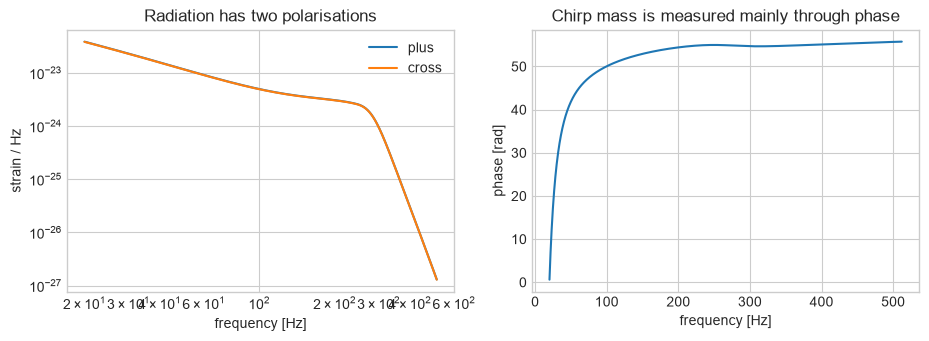

In [4]:
fig,axes=plt.subplots(1,2,figsize=(11,3.4))
for name,h in injection_polarizations.items(): axes[0].loglog(frequency[mask],np.abs(h[mask]),label=name)
axes[0].set(xlabel="frequency [Hz]",ylabel="strain / Hz",title="Radiation has two polarisations"); axes[0].legend()
axes[1].plot(frequency[mask],np.unwrap(np.angle(injection_polarizations["plus"][mask])))
axes[1].set(xlabel="frequency [Hz]",ylabel="phase [rad]",title="Chirp mass is measured mainly through phase"); plt.show()

For a non-precessing circular binary, approximately
$h_+\propto(1+\cos^2\iota)/(2D_L)$ and $h_\times\propto\cos\iota/D_L$.
Inclination is the binary's orientation to us; polarisation angle rotates the plus/cross basis on the sky.

In [5]:
frames=np.linspace(float(theta_true[0])-6,float(theta_true[0])+6,28)
fig,(aa,ap)=plt.subplots(1,2,figsize=(11,3.3)); la,=aa.loglog([],[]); lp,=ap.plot([],[])
aa.set(xlim=(20,512),ylim=(1e-25,3e-22),xlabel="frequency [Hz]",ylabel=r"$|h_+|$")
ap.set(xlim=(20,512),ylim=(-650,50),xlabel="frequency [Hz]",ylabel="relative phase [rad]")
def animate_mass(i):
    h=polarizations(theta_true.at[0].set(frames[i]))["plus"][mask]; phase=np.unwrap(np.angle(h)); phase-=phase[0]
    la.set_data(frequency[mask],np.abs(h)); lp.set_data(frequency[mask],phase); fig.suptitle(f"chirp mass = {frames[i]:.1f} solar masses"); return la,lp
animation=FuncAnimation(fig,animate_mass,frames=len(frames),interval=130); plt.close(fig); display(HTML(animation.to_jshtml()))

## 2. From source to a detector network

For detector $I$,
\[
\tilde h_I=[F^I_+h_++F^I_\times h_\times]e^{-2\pi if\Delta t_I}.
\]
Bilby stores detector geometry and PSDs and applies this projection. This is the machinery that a high-level CBC likelihood normally hides.

In [6]:
source_parameters=dict(ra=1.2,dec=-.4,psi=.7,geocent_time=gps_time)
ifos=bilby.gw.detector.InterferometerList(["H1","L1","V1"])
for ifo in ifos: ifo.set_strain_data_from_zero_noise(sampling_frequency=sample_rate,duration=duration,start_time=gps_time-2)
print("IFO     F+      Fx      delay [ms]")
for ifo in ifos:
    fp=ifo.antenna_response(source_parameters["ra"],source_parameters["dec"],gps_time,source_parameters["psi"],"plus")
    fx=ifo.antenna_response(source_parameters["ra"],source_parameters["dec"],gps_time,source_parameters["psi"],"cross")
    dt=ifo.time_delay_from_geocenter(source_parameters["ra"],source_parameters["dec"],gps_time)
    print(f"{ifo.name:>3}  {fp:+.3f}  {fx:+.3f}   {1e3*dt:+.2f}")

IFO     F+      Fx      delay [ms]
 H1  +0.366  +0.334   -3.18
 L1  -0.263  -0.597   -11.80
 V1  +0.108  -0.159   +3.83


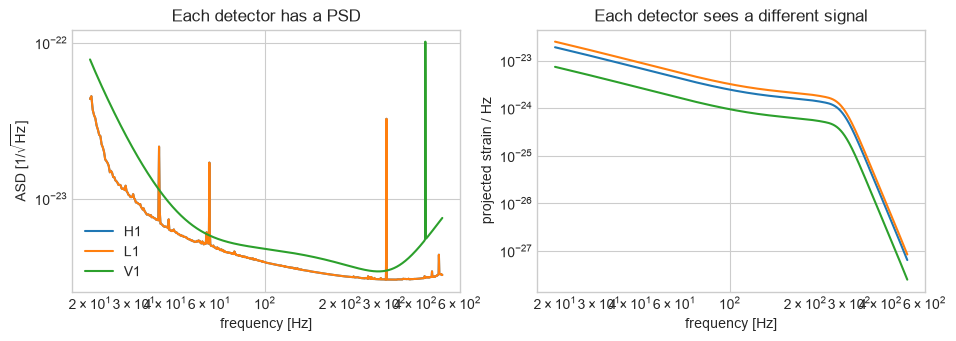

In [7]:
fig,axes=plt.subplots(1,2,figsize=(11,3.4))
for ifo in ifos:
    asd=ifo.power_spectral_density.get_amplitude_spectral_density_array(frequency)
    axes[0].loglog(frequency[mask],asd[mask],label=ifo.name)
    response=ifo.get_detector_response(injection_polarizations,source_parameters,frequencies=frequency)
    axes[1].loglog(frequency[mask],np.abs(response[mask]),label=ifo.name)
axes[0].set(xlabel="frequency [Hz]",ylabel=r"ASD [1/$\sqrt{\mathrm{Hz}}$]",title="Each detector has a PSD")
axes[1].set(xlabel="frequency [Hz]",ylabel="projected strain / Hz",title="Each detector sees a different signal")
for ax in axes: ax.legend(); plt.show()

## 3. Inject and infer

We use zero-noise data so the demonstration is deterministic: the data equal the injected signal, while the PSD still controls expected uncertainty. Replace `set_strain_data_from_zero_noise` with Bilby's PSD-noise method to study repeated noise realisations.

Network optimal SNR: 34.98


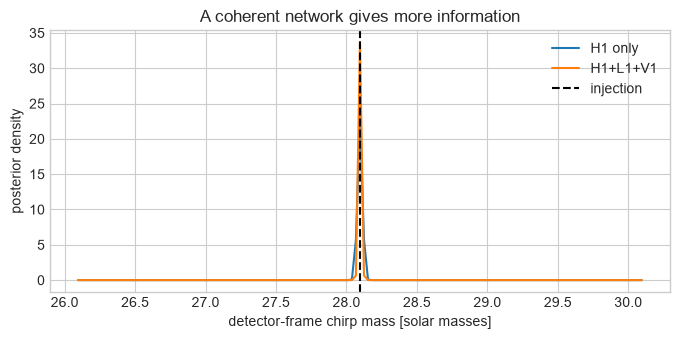

In [8]:
for ifo in ifos: ifo.inject_signal_from_waveform_polarizations(source_parameters,injection_polarizations)
print("Network optimal SNR:",round(np.sqrt(sum(ifo.meta_data["optimal_SNR"]**2 for ifo in ifos)),2))

def detector_log_likelihood(ifo,model_polarizations):
    model=ifo.get_detector_response(model_polarizations,source_parameters,frequencies=frequency)
    residual=ifo.frequency_domain_strain-model
    psd=ifo.power_spectral_density_array
    return -2*df*np.sum(np.abs(residual[mask])**2/psd[mask])

mass_grid=np.linspace(float(theta_true[0])-2,float(theta_true[0])+2,141)
logL_by_ifo={ifo.name:[] for ifo in ifos}
for mc in mass_grid:
    model=polarizations(theta_true.at[0].set(mc))
    for ifo in ifos: logL_by_ifo[ifo.name].append(detector_log_likelihood(ifo,model))
logL_network=np.sum([logL_by_ifo[name] for name in logL_by_ifo],axis=0)
def density(logp):
    p=np.exp(logp-np.max(logp)); return p/np.trapezoid(p,mass_grid)
fig,ax=plt.subplots(figsize=(8,3.4)); ax.plot(mass_grid,density(np.array(logL_by_ifo["H1"])),label="H1 only")
ax.plot(mass_grid,density(logL_network),label="H1+L1+V1"); ax.axvline(float(theta_true[0]),color="k",ls="--",label="injection")
ax.set(xlabel="detector-frame chirp mass [solar masses]",ylabel="posterior density",title="A coherent network gives more information"); ax.legend(); plt.show()

## 4. Why a network localises the sky

Timing alone gives a ring with two sites and smaller regions with three. Real Bilby localisation also uses coherent phase, antenna amplitudes, polarisation, distance–inclination correlations, waveform uncertainty, and sky priors.

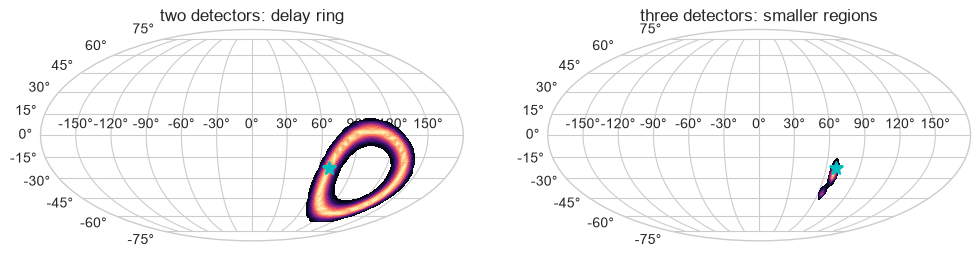

In [9]:
ra=np.linspace(-np.pi,np.pi,91); dec=np.linspace(-np.pi/2,np.pi/2,46); RA,DEC=np.meshgrid(ra,dec)
delays={ifo.name:np.array([[ifo.time_delay_from_geocenter(r,d,gps_time) for r in ra] for d in dec]) for ifo in ifos}
observed={ifo.name:ifo.time_delay_from_geocenter(source_parameters["ra"],source_parameters["dec"],gps_time) for ifo in ifos}; sigma_t=3e-4
def timing_likelihood(names):
    ref=names[0]; value=np.zeros_like(RA)
    for name in names[1:]: value-=.5*((delays[name]-delays[ref]-(observed[name]-observed[ref]))/sigma_t)**2
    return value
fig,axes=plt.subplots(1,2,figsize=(12,4),subplot_kw={"projection":"mollweide"})
for ax,names,title in zip(axes,[["H1","L1"],["H1","L1","V1"]],["two detectors: delay ring","three detectors: smaller regions"]):
    ll=timing_likelihood(names); sky=np.exp(ll-ll.max()); ax.contourf(RA,DEC,sky,levels=np.linspace(.05,1,15),cmap="magma")
    ax.plot(source_parameters["ra"],source_parameters["dec"],"c*",ms=10); ax.set_title(title); ax.grid(True)
plt.show()

## 5. Bilby production composition

```python
waveform_generator = bilby.gw.WaveformGenerator(...)
likelihood = bilby.gw.likelihood.GravitationalWaveTransient(
    interferometers=ifos, waveform_generator=waveform_generator)
result = bilby.run_sampler(likelihood, priors, sampler="dynesty", ...)
```

Bilby then handles response projection, detector likelihoods, common parameters, priors, marginalisations, and sampler results. Yay Bilby.

## Boundary and extensions

- The live posterior frees only chirp mass; production BBH analyses may have about fifteen parameters plus nuisance/systematic choices.
- Design PSDs and zero noise are pedagogical. Real data contain PSD uncertainty, lines, glitches, non-stationarity, and calibration uncertainty.
- Use the NZ workshop's GW150914 section or [GWOSC tutorials](https://gwosc.org/tutorials/) as a real-data follow-up.

Adapted substantially from `nz_bilby_cbc_workshop_2024`, with its injection → PSD → prior → likelihood → result structure.